# Zadanie 2 — Feature Engineering (SQL + Python)

## 2.0 Importy i dane wejściowe

In [1]:
import json
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import wkt
from sklearn.neighbors import BallTree
import snowflake.connector
import warnings
warnings.filterwarnings('ignore')

with open('../credentials/credentials.json') as f:
    creds = json.load(f)

# Pliki CSV
locations = pd.read_csv('../dane/ds_locations.csv')
competitors = pd.read_csv('../dane/ds_competitors.csv')
poi = pd.read_csv('../dane/ds_poi.csv')
area_df = pd.read_csv('../dane/ds_analysis_area.csv')
districts_df = pd.read_csv('../dane/ds_districts.csv')

area_poly = wkt.loads(area_df['geometry'].iloc[0])
lng_min, lat_min, lng_max, lat_max = area_poly.bounds

# Dane z S3
buildings = pd.read_csv('../data/raw/buildings.csv.gz',  compression='gzip')
population = pd.read_csv('../data/raw/population.csv.gz', compression='gzip')

print('Dane wczytane.')
print(f'Lokalizacje: {len(locations)}, Dzielnice: {len(districts_df)}, Konkurencja: {len(competitors)}')
print(f'POI: {len(poi)}, Budynki: {len(buildings):,}, Populacja: {len(population):,}')

Dane wczytane.
Lokalizacje: 50, Dzielnice: 15, Konkurencja: 98
POI: 335, Budynki: 955,612, Populacja: 450,140


## 2.1 GeoDataFrames i bufory

In [2]:
# Lokalizacje klienta w EPSG:2180
locations_gdf = gpd.GeoDataFrame(
    locations,
    geometry=gpd.points_from_xy(locations.lng, locations.lat),
    crs=4326
).to_crs(2180)

# Bufory wielu promieni — krótkie (lokalny catchment) + długie (kontekst regionalny)
RADII = [500, 1000, 2000, 3000]
buffers = {}
for r in RADII:
    g = locations_gdf[['location_id', 'geometry']].copy()
    g['geometry'] = g.geometry.buffer(r)
    buffers[r] = g

# Aliasy używane dalej
buf500, buf1000, buf2000, buf3000 = buffers[500], buffers[1000], buffers[2000], buffers[3000]

print(f'Bufory wygenerowane dla promieni {RADII} m × {len(locations_gdf)} lokalizacji.')

Bufory wygenerowane dla promieni [500, 1000, 2000, 3000] m × 50 lokalizacji.


## 2.2 Ruch pieszy — Snowflake SQL

In [3]:
sf = creds['snowflake']
conn = snowflake.connector.connect(
    account=sf['account'],
    user=sf['user'],
    password=sf['password'],
    warehouse=sf['warehouse'],
    database=sf['database'],
    schema=sf['schema'],
    role=sf['role']
)
cur = conn.cursor()
print('Połączono ze Snowflake.')

Połączono ze Snowflake.


In [4]:
# Multi-radius footfall query: filtrujemy raz do max promienia (2000m), liczymy wszystkie progi w jednym GROUP BY.
values_rows = ',\n        '.join(
    f"('{row.location_id}', {row.lat}, {row.lng})"
    for _, row in locations.iterrows()
)

footfall_sql = f'''
WITH locs AS (
    SELECT column1 AS location_id,
           ST_MAKEPOINT(column3, column2) AS geom
    FROM VALUES
        {values_rows}
),
filtered AS (
    SELECT
        l.location_id,
        t.proxi_user_id,
        DATE(TO_TIMESTAMP_NTZ(t.occured_at)) AS dt,
        ST_DISTANCE(
            ST_MAKEPOINT(TRY_CAST(t.longitude AS FLOAT), TRY_CAST(t.latitude AS FLOAT)),
            l.geom
        ) AS dist_m
    FROM RECRUITMENT_TRACES t
    CROSS JOIN locs l
    WHERE TRY_CAST(t.latitude  AS FLOAT) BETWEEN {lat_min} AND {lat_max}
      AND TRY_CAST(t.longitude AS FLOAT) BETWEEN {lng_min} AND {lng_max}
      AND ST_DISTANCE(
            ST_MAKEPOINT(TRY_CAST(t.longitude AS FLOAT), TRY_CAST(t.latitude AS FLOAT)),
            l.geom
          ) <= 2000
)
SELECT
    location_id,
    COUNT_IF(dist_m <= 500)                                           AS traces_500m,
    COUNT_IF(dist_m <= 2000)                                          AS traces_2000m,
    COUNT(DISTINCT CASE WHEN dist_m <= 500  THEN proxi_user_id END)   AS devices_500m,
    COUNT(DISTINCT CASE WHEN dist_m <= 2000 THEN proxi_user_id END)   AS devices_2000m,
    COUNT(DISTINCT CASE WHEN dist_m <= 500  THEN dt END)              AS active_days_500m,
    COUNT(DISTINCT CASE WHEN dist_m <= 2000 THEN dt END)              AS active_days_2000m
FROM filtered
GROUP BY location_id
'''

print('Wysyłam zapytanie do Snowflake (multi-radius — może potrwać kilka minut)...')
cur.execute(footfall_sql)
footfall = pd.DataFrame(
    cur.fetchall(),
    columns=['location_id', 'traces_500m', 'traces_2000m',
             'devices_500m', 'devices_2000m',
             'active_days_500m', 'active_days_2000m']
)

# Cechy intensywności — odporne na "skalę miasta": traces na unikalne urządzenie i na dzień.
for r in [500, 2000]:
    devs = footfall[f'devices_{r}m'].replace(0, np.nan)
    days = footfall[f'active_days_{r}m'].replace(0, np.nan)
    footfall[f'traces_per_device_{r}m'] = (footfall[f'traces_{r}m'] / devs).fillna(0)
    footfall[f'traces_per_day_{r}m']    = (footfall[f'traces_{r}m'] / days).fillna(0)

print(f'Pobrano: {len(footfall)} wierszy, {footfall.shape[1]-1} cech ruchu pieszego.')
footfall.head()

Wysyłam zapytanie do Snowflake (multi-radius — może potrwać kilka minut)...
Pobrano: 50 wierszy, 10 cech ruchu pieszego.


,location_id,traces_500m,traces_2000m,devices_500m,devices_2000m,active_days_500m,active_days_2000m,traces_per_device_500m,traces_per_day_500m,traces_per_device_2000m,traces_per_day_2000m
0,LOC_003,6312,161913,341,2954,17,66,18.510264,371.294118,54.811442,2453.227273
1,LOC_030,14659,209396,395,2252,22,61,37.111392,666.318182,92.982238,3432.721311
2,LOC_046,6864,99998,170,1234,14,51,40.376471,490.285714,81.035656,1960.745098
3,LOC_040,2175,79511,209,1421,12,57,10.406699,181.250000,55.954258,1394.929825
4,LOC_049,14475,249490,367,3160,37,97,39.441417,391.216216,78.952532,2572.061856


In [5]:
cur.close()
conn.close()
print('Połączenie ze Snowflake zamknięte.')

Połączenie ze Snowflake zamknięte.


## 2.3 Zabudowa — geopandas buffer + sjoin

In [6]:
print('Parsowanie geometrii budynków...')
buildings_gdf = gpd.GeoDataFrame(
    buildings,
    geometry=gpd.GeoSeries.from_wkt(buildings['geometry'], crs=4326),
    crs=4326
).to_crs(2180)

# Zachowaj tylko potrzebne kolumny
buildings_gdf = buildings_gdf[['teryt', 'funogolnabudynku_desc', 'funszczegolowabudynku_desc', 'area', 'geometry']]
print(f'Budynki jako GeoDataFrame: {len(buildings_gdf):,}')

Parsowanie geometrii budynków...
Budynki jako GeoDataFrame: 955,612


In [7]:
RESIDENTIAL = {
    'budynkiMieszkalneJednorodzinne', 'budynkiODwochMieszkaniach',
    'budynkiOTrzechIWiecejMieszkaniach', 'budynkiZbiorowegoZamieszkania',
}
COMMERCIAL = {
    'budynkiHandlowoUslugowe', 'budynkiBiurowe', 'budynkiHoteli',
    'ogolnodostepneObiektyKulturalne', 'budynkiLacznosciDworcowITerminali',
}
INDUSTRIAL = {'budynkiPrzemyslowe', 'zbiornikSilosIBudynkiMagazynowe'}
PUBLIC = {
    'budynkiSzkolIInstytucjiBadawczych', 'budynkiSzpitaliIZakladowOpiekiMedycznej',
    'budynkiKultuReligijnego', 'budynkiKulturyFizycznej', 'budynkiMuzeowIBibliotek',
}

buildings_gdf['is_residential'] = buildings_gdf['funogolnabudynku_desc'].isin(RESIDENTIAL)
buildings_gdf['is_commercial']  = buildings_gdf['funogolnabudynku_desc'].isin(COMMERCIAL)
buildings_gdf['is_industrial']  = buildings_gdf['funogolnabudynku_desc'].isin(INDUSTRIAL)
buildings_gdf['is_public']      = buildings_gdf['funogolnabudynku_desc'].isin(PUBLIC)

# area-weighted: udział powierzchni > udziału liczby (galeria handlowa = 1 budynek o 80k m²)
for cls in ['residential', 'commercial', 'industrial', 'public']:
    buildings_gdf[f'area_{cls}'] = buildings_gdf['area'] * buildings_gdf[f'is_{cls}']

def building_features_for_radius(buf_gdf, radius_m):
    joined = gpd.sjoin(buildings_gdf, buf_gdf.to_crs(2180), how='inner', predicate='intersects')
    buffer_area_km2 = (np.pi * radius_m ** 2) / 1_000_000  # stała dla wszystkich lokalizacji

    agg = joined.groupby('location_id').agg(
        buildings_count=('teryt', 'count'),
        total_building_area=('area', 'sum'),
        residential_area=('area_residential', 'sum'),
        commercial_area=('area_commercial', 'sum'),
        industrial_area=('area_industrial', 'sum'),
        public_area=('area_public', 'sum'),
        residential_count=('is_residential', 'sum'),
        commercial_count=('is_commercial', 'sum'),
    ).reset_index()

    # Udziały po POWIERZCHNI (lepsze niż po liczbie dla mixed-use)
    total = agg['total_building_area'].replace(0, np.nan)
    for cls in ['residential', 'commercial', 'industrial', 'public']:
        agg[f'{cls}_area_share'] = (agg[f'{cls}_area'] / total).fillna(0)

    # Gęstość zabudowy (powierzchnia budynków / powierzchnia bufora)
    agg['building_floor_ratio'] = agg['total_building_area'] / (buffer_area_km2 * 1_000_000)
    agg['buildings_density_per_km2'] = agg['buildings_count'] / buffer_area_km2

    # Suffix per-radius
    rename = {c: f'{c}_{radius_m}m' for c in agg.columns if c != 'location_id'}
    return agg.rename(columns=rename)

bf_1000 = building_features_for_radius(buf1000, 1000)
bf_3000 = building_features_for_radius(buf3000, 3000)
building_features = bf_1000.merge(bf_3000, on='location_id', how='outer')

print(f'Building features: {len(building_features)} lokalizacji × {building_features.shape[1]-1} cech')
building_features.describe().T[['mean', 'std', 'min', 'max']].round(2).head(15)

Building features: 50 lokalizacji × 28 cech


,mean,std,min,max
buildings_count_1000m,1478.34,697.97,176.00,3239.00
total_building_area_1000m,339012.61,184421.61,25986.85,818987.12
residential_area_1000m,170979.99,91371.42,12988.30,452364.65
commercial_area_1000m,65776.41,54908.17,5770.40,267390.28
industrial_area_1000m,37462.87,38392.54,804.21,206194.21
public_area_1000m,27539.87,28786.51,0.00,136930.71
residential_count_1000m,877.34,415.33,88.00,1852.00
commercial_count_1000m,129.62,87.42,10.00,363.00
residential_area_share_1000m,0.52,0.12,0.22,0.73
commercial_area_share_1000m,0.17,0.08,0.05,0.37


## 2.4 Demografia — spatial join populacji

In [8]:
pop_gdf = gpd.GeoDataFrame(
    population,
    geometry=gpd.points_from_xy(population.lng, population.lat),
    crs=4326
).to_crs(2180)

# Filtr ekstremów (jak wcześniej) — stosujemy raz, niezależnie od bufora
pop_gdf = pop_gdf[(pop_gdf['household_size'] > 0) & (pop_gdf['household_size'] <= 10)].copy()

def population_features_for_radius(buf_gdf, radius_m):
    joined = gpd.sjoin(pop_gdf, buf_gdf.to_crs(2180), how='inner', predicate='within')
    buffer_area_km2 = (np.pi * radius_m ** 2) / 1_000_000

    agg = joined.groupby('location_id').apply(
        lambda x: pd.Series({
            'population_total':   x['total'].sum(),
            'households_count':   x['households'].sum(),
            # Średnia wielkość gosp. domowego ważona LICZBĄ GOSPODARSTW (nie populacją)
            'avg_household_size': (
                (x['household_size'] * x['households']).sum() / x['households'].sum()
                if x['households'].sum() > 0 else np.nan
            ),
            'female_share': (
                x['female'].sum() / x['total'].sum()
                if x['total'].sum() > 0 else np.nan
            ),
        })
    ).reset_index()

    # Prawdziwa gęstość: osób na km² powierzchni bufora (nie per-grid-cell)
    agg['population_per_km2'] = agg['population_total'] / buffer_area_km2
    agg['households_per_km2'] = agg['households_count'] / buffer_area_km2

    rename = {c: f'{c}_{radius_m}m' for c in agg.columns if c != 'location_id'}
    return agg.rename(columns=rename)

pop_1000 = population_features_for_radius(buf1000, 1000)
pop_3000 = population_features_for_radius(buf3000, 3000)
pop_features = pop_1000.merge(pop_3000, on='location_id', how='outer')

print(f'Population features: {len(pop_features)} lokalizacji × {pop_features.shape[1]-1} cech')
pop_features.describe().T[['mean', 'std', 'min', 'max']].round(2).head(15)

Population features: 50 lokalizacji × 12 cech


,mean,std,min,max
population_total_1000m,11437.52,7674.51,340.00,30668.00
households_count_1000m,4617.34,3342.42,76.00,12822.00
avg_household_size_1000m,2.76,0.63,1.94,4.47
female_share_1000m,0.53,0.01,0.51,0.55
population_per_km2_1000m,3640.68,2442.87,108.23,9761.93
households_per_km2_1000m,1469.74,1063.92,24.19,4081.37
population_total_3000m,62237.62,39332.24,5959.00,168488.00
households_count_3000m,24954.18,16481.18,1513.00,65977.00
avg_household_size_3000m,2.73,0.53,2.13,4.04
female_share_3000m,0.53,0.01,0.50,0.54


## 2.5 POI — multi-radius + cechy ważone odległością

Standardowy `sjoin` traktuje POI 50m i 1900m jednakowo. Dodajemy więc cechy z malejącą wagą gaussowską `exp(-d/scale)`, gdzie `scale=500m` — POI w odległości 500m liczy się ~37% tak samo jak ten 0m, POI 1500m → 5%.

In [9]:
poi_gdf = gpd.GeoDataFrame(
    poi,
    geometry=gpd.points_from_xy(poi.lng, poi.lat),
    crs=4326
).to_crs(2180)

POI_CATEGORIES = ['restaurant', 'bank', 'school', 'pharmacy', 'hospital', 'mall', 'park']

def poi_count_features_for_radius(buf_gdf, radius_m):
    joined = gpd.sjoin(poi_gdf, buf_gdf.to_crs(2180), how='inner', predicate='within')
    base = pd.DataFrame({'location_id': locations['location_id']})

    agg_kwargs = {f'poi_total_{radius_m}m': ('poi_id', 'count')}
    for cat in POI_CATEGORIES:
        # closure capture
        agg_kwargs[f'{cat}_count_{radius_m}m'] = ('category', (lambda c: lambda x: (x == c).sum())(cat))
    agg = joined.groupby('location_id').agg(**agg_kwargs).reset_index()

    return base.merge(agg, on='location_id', how='left').fillna(0)

# Distance-weighted (gaussian decay, scale=500m). Wymaga jawnego liczenia odległości od każdej lokalizacji.
def poi_decay_features(scale_m=500.0, max_dist_m=3000.0):
    loc_pts = locations_gdf[['location_id', 'geometry']].copy()
    loc_coords = np.array([[g.x, g.y] for g in loc_pts.geometry])
    poi_coords = np.array([[g.x, g.y] for g in poi_gdf.geometry])
    poi_cats = poi_gdf['category'].values

    rows = []
    for i, loc_id in enumerate(loc_pts['location_id']):
        d = np.sqrt(((poi_coords - loc_coords[i]) ** 2).sum(axis=1))
        mask = d <= max_dist_m
        w = np.exp(-d[mask] / scale_m)
        cats_in = poi_cats[mask]

        rec = {'location_id': loc_id, 'poi_decay_total': w.sum()}
        for cat in POI_CATEGORIES:
            rec[f'{cat}_decay'] = w[cats_in == cat].sum()
        rows.append(rec)
    return pd.DataFrame(rows)

poi_500  = poi_count_features_for_radius(buf500, 500)
poi_2000 = poi_count_features_for_radius(buf2000, 2000)
poi_decay = poi_decay_features()

poi_features = poi_500.merge(poi_2000, on='location_id', how='outer').merge(poi_decay, on='location_id', how='outer')

print(f'POI features: {len(poi_features)} lokalizacji × {poi_features.shape[1]-1} cech')
poi_features.describe().T[['mean', 'std', 'min', 'max']].round(2).head(15)

POI features: 50 lokalizacji × 24 cech


,mean,std,min,max
poi_total_500m,0.42,0.76,0.0,3.0
restaurant_count_500m,0.08,0.34,0.0,2.0
bank_count_500m,0.08,0.27,0.0,1.0
school_count_500m,0.12,0.33,0.0,1.0
pharmacy_count_500m,0.06,0.24,0.0,1.0
hospital_count_500m,0.02,0.14,0.0,1.0
mall_count_500m,0.04,0.20,0.0,1.0
park_count_500m,0.02,0.14,0.0,1.0
poi_total_2000m,4.82,4.54,0.0,20.0
restaurant_count_2000m,1.22,2.09,0.0,12.0


## 2.6 Konkurencja — multi-radius + dystans do dyskontów

- **Sklepy convenience (Żabka et al.)** — krótkie bufory (1000m, 2000m), bo gęstość duża.
- **Dyskonty (Lidl/Aldi/Netto)** — bufor 3000m, bo średnia odległość ~9km. Dodajemy też `dist_nearest_discount` jako cechę ciągłą (niezależną od progu).
- **Distance-decay** (`exp(-d/1000)`) dla wszystkich konkurentów — większa waga dla bliższych.

In [10]:
discounts = competitors[competitors['brand'].isin(['Lidl','Aldi','Netto'])]

discount_gdf = gpd.GeoDataFrame(
    discounts,
    geometry=gpd.points_from_xy(discounts.lng, discounts.lat),
    crs="EPSG:4326"
).to_crs(epsg=2180)

tree = BallTree(
    np.radians(discount_gdf[['lat','lng']].values),
    metric='haversine'
)

dist, _ = tree.query(np.radians(locations[['lat','lng']].values), k=1)

print(np.min(dist * 6371000), np.mean(dist * 6371000))

1279.3301016956343 9033.49288862537


In [11]:
DISCOUNT_BRANDS = ['Lidl', 'Aldi', 'Netto']
CONVENIENCE_BRANDS = ['Żabka', 'Carrefour Express', 'Freshmarket']

# 1) Distances (haversine, niezależne od buforów)
loc_coords_rad = np.radians(locations[['lat', 'lng']].values)

def nearest_dist_m(subset_df):
    if len(subset_df) == 0:
        return np.full(len(locations), np.inf)
    coords = np.radians(subset_df[['lat', 'lng']].values)
    tree = BallTree(coords, metric='haversine')
    dist, _ = tree.query(loc_coords_rad, k=1)
    return dist[:, 0] * 6371000

dist_features = pd.DataFrame({'location_id': locations['location_id']})
dist_features['dist_nearest_competitor'] = nearest_dist_m(competitors)
dist_features['dist_nearest_discount']   = nearest_dist_m(competitors[competitors['brand'].isin(DISCOUNT_BRANDS)])
dist_features['dist_nearest_zabka']      = nearest_dist_m(competitors[competitors['brand'] == 'Żabka'])
dist_features['dist_nearest_convenience'] = nearest_dist_m(competitors[competitors['brand'].isin(CONVENIENCE_BRANDS)])
# log-przekształcenie odległości (silnie skośne)
for col in ['dist_nearest_competitor', 'dist_nearest_discount', 'dist_nearest_zabka', 'dist_nearest_convenience']:
    dist_features[f'log_{col}'] = np.log1p(dist_features[col])

# 2) Counts per radius
comp_gdf = gpd.GeoDataFrame(
    competitors, geometry=gpd.points_from_xy(competitors.lng, competitors.lat), crs=4326
).to_crs(2180)

def comp_counts_for_radius(buf_gdf, radius_m, restrict_brands=None):
    g = comp_gdf
    if restrict_brands is not None:
        g = comp_gdf[comp_gdf['brand'].isin(restrict_brands)]
    joined = gpd.sjoin(g, buf_gdf.to_crs(2180), how='inner', predicate='within')
    base = pd.DataFrame({'location_id': locations['location_id']})
    return base.merge(
        joined.groupby('location_id').size().rename(f'count_{radius_m}m').reset_index(),
        on='location_id', how='left'
    ).fillna(0)

# Convenience/Żabka — krótkie bufory
conv_1000 = comp_counts_for_radius(buf1000, 1000, CONVENIENCE_BRANDS).rename(columns={'count_1000m': 'convenience_count_1000m'})
conv_2000 = comp_counts_for_radius(buf2000, 2000, CONVENIENCE_BRANDS).rename(columns={'count_2000m': 'convenience_count_2000m'})
zabka_1000 = comp_counts_for_radius(buf1000, 1000, ['Żabka']).rename(columns={'count_1000m': 'zabka_count_1000m'})
zabka_2000 = comp_counts_for_radius(buf2000, 2000, ['Żabka']).rename(columns={'count_2000m': 'zabka_count_2000m'})
# Dyskonty — duży bufor (≤9 km średnio do najbliższego)
disc_3000 = comp_counts_for_radius(buf3000, 3000, DISCOUNT_BRANDS).rename(columns={'count_3000m': 'discount_count_3000m'})
# Wszyscy razem
all_2000 = comp_counts_for_radius(buf2000, 2000).rename(columns={'count_2000m': 'competitors_total_2000m'})
all_3000 = comp_counts_for_radius(buf3000, 3000).rename(columns={'count_3000m': 'competitors_total_3000m'})

# 3) Brand diversity (2000m)
joined_all = gpd.sjoin(comp_gdf, buf2000.to_crs(2180), how='inner', predicate='within')
brand_div = joined_all.groupby('location_id')['brand'].nunique().rename('brand_diversity_2000m').reset_index()

# 4) Distance-decay (jeden agregat dla wszystkich konkurentów, scale=1000m, max=5km)
loc_xy = np.array([[g.x, g.y] for g in locations_gdf.geometry])
comp_xy = np.array([[g.x, g.y] for g in comp_gdf.geometry])
comp_brands = comp_gdf['brand'].values

decay_rows = []
for i, loc_id in enumerate(locations_gdf['location_id']):
    d = np.sqrt(((comp_xy - loc_xy[i]) ** 2).sum(axis=1))
    mask = d <= 5000
    w = np.exp(-d[mask] / 1000.0)
    brands_in = comp_brands[mask]
    decay_rows.append({
        'location_id': loc_id,
        'comp_decay_total': w.sum(),
        'comp_decay_zabka': w[brands_in == 'Żabka'].sum(),
        'comp_decay_discount': w[np.isin(brands_in, DISCOUNT_BRANDS)].sum(),
    })
decay_df = pd.DataFrame(decay_rows)

# 5) Merge
comp_features = (
    dist_features
    .merge(conv_1000,  on='location_id', how='left')
    .merge(conv_2000,  on='location_id', how='left')
    .merge(zabka_1000, on='location_id', how='left')
    .merge(zabka_2000, on='location_id', how='left')
    .merge(disc_3000,  on='location_id', how='left')
    .merge(all_2000,   on='location_id', how='left')
    .merge(all_3000,   on='location_id', how='left')
    .merge(brand_div,  on='location_id', how='left')
    .merge(decay_df,   on='location_id', how='left')
)
fill_zero = [c for c in comp_features.columns
             if c != 'location_id' and not c.startswith('dist_') and not c.startswith('log_dist_')]
comp_features[fill_zero] = comp_features[fill_zero].fillna(0)

print(f'Competitor features: {len(comp_features)} lokalizacji × {comp_features.shape[1]-1} cech')
comp_features.describe().T[['mean', 'std', 'min', 'max']].round(2).head(20)

Competitor features: 50 lokalizacji × 19 cech


,mean,std,min,max
dist_nearest_competitor,2540.26,2866.45,42.16,13836.88
dist_nearest_discount,9033.49,5172.78,1279.33,29323.61
dist_nearest_zabka,3673.07,4335.09,67.25,19348.54
dist_nearest_convenience,3673.07,4335.09,67.25,19348.54
log_dist_nearest_competitor,7.32,1.14,3.76,9.54
log_dist_nearest_discount,8.92,0.67,7.15,10.29
log_dist_nearest_zabka,7.65,1.13,4.22,9.87
log_dist_nearest_convenience,7.65,1.13,4.22,9.87
convenience_count_1000m,0.18,0.39,0.00,1.00
convenience_count_2000m,0.74,0.92,0.00,3.00


## 2.7 Merge wszystkich cech

In [12]:
# District assignment (do spatial CV w nb 03 — NIE jako predyktor)
districts_gdf = gpd.GeoDataFrame(
    districts_df,
    geometry=districts_df['geometry'].apply(wkt.loads),
    crs=4326
).to_crs(2180)

loc_with_district = gpd.sjoin(
    locations_gdf[['location_id', 'geometry']],
    districts_gdf[['district_id', 'name', 'geometry']],
    how='left', predicate='within'
)[['location_id', 'district_id', 'name']].rename(columns={'name': 'district_name'})

unmatched = loc_with_district['district_id'].isna().sum()
if unmatched > 0:
    # Fallback: nearest district dla lokalizacji poza poligonami
    print(f'Uwaga: {unmatched} lokalizacji poza wszystkimi poligonami dzielnic — przypisuję najbliższą.')
    missing = loc_with_district['district_id'].isna()
    nearest = gpd.sjoin_nearest(
        locations_gdf[missing][['location_id', 'geometry']],
        districts_gdf[['district_id', 'name', 'geometry']],
        how='left'
    )[['location_id', 'district_id', 'name']]
    loc_with_district = loc_with_district[~missing].copy()
    loc_with_district = pd.concat([
        loc_with_district,
        nearest.rename(columns={'name': 'district_name'})
    ]).reset_index(drop=True)

# Merge wszystkich cech
features = locations[['location_id', 'lat', 'lng', 'monthly_revenue']].copy()
features = features.merge(loc_with_district, on='location_id', how='left')

for df in [footfall, building_features, pop_features, poi_features, comp_features]:
    features = features.merge(df, on='location_id', how='left')

# fillna(0) dla cech licznikowych; dystanse → infinity nie powinny się zdarzyć (każdy ma najbliższego konkurenta),
# ale na wszelki wypadek wypełnimy duża wartością
inf_cols = features.select_dtypes(include=np.number).columns
features[inf_cols] = features[inf_cols].replace([np.inf, -np.inf], np.nan)

# Cechy odległościowe wypełnij medianą (zachowanie skali); reszta → 0
dist_cols = [c for c in features.columns if c.startswith('dist_') or c.startswith('log_dist_')]
for c in dist_cols:
    features[c] = features[c].fillna(features[c].median())

other_numeric = [c for c in features.select_dtypes(include=np.number).columns if c not in dist_cols]
features[other_numeric] = features[other_numeric].fillna(0)

print(f'Feature matrix: {features.shape}')
print(f'Dzielnice obecne: {features["district_id"].nunique()}  (dla GroupKFold)')
print(f'Sklepów per dzielnica:\n{features["district_name"].value_counts().to_string()}')
print(f'\nBraki danych:\n{features.isnull().sum()[features.isnull().sum() > 0]}')
features.head()

Uwaga: 2 lokalizacji poza wszystkimi poligonami dzielnic — przypisuję najbliższą.
Feature matrix: (50, 99)
Dzielnice obecne: 14  (dla GroupKFold)
Sklepów per dzielnica:
district_name
Kraków               14
Katowice              8
Gliwice               8
Bytom                 5
Sosnowiec             3
Olkusz                2
powiat wielicki       2
Tychy                 2
Rybnik                1
Dąbrowa Górnicza      1
Jaworzno              1
powiat pszczyński     1
Chrzanów              1
powiat krakowski      1

Braki danych:
Series([], dtype: int64)


,location_id,lat,lng,monthly_revenue,district_id,district_name,traces_500m,traces_2000m,devices_500m,devices_2000m,...,convenience_count_2000m,zabka_count_1000m,zabka_count_2000m,discount_count_3000m,competitors_total_2000m,competitors_total_3000m,brand_diversity_2000m,comp_decay_total,comp_decay_zabka,comp_decay_discount
0,LOC_001,50.226272,19.072973,245633.74,2401.0,Katowice,17537,60503,275,912,...,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.822327,0.822327,0.000000
1,LOC_002,50.299999,18.674625,333393.33,2403.0,Gliwice,27611,326556,654,3216,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.086505,0.076730,0.009775
2,LOC_003,50.042894,19.968676,296109.69,2404.0,Kraków,6312,161913,341,2954,...,2.0,1.0,2.0,0.0,3.0,6.0,2.0,1.609825,1.070756,0.000000
3,LOC_004,50.130954,19.607709,197099.19,2408.0,Olkusz,923,11721,29,307,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
4,LOC_005,50.351594,18.894944,292786.56,2412.0,Bytom,29446,253366,408,2665,...,1.0,0.0,1.0,0.0,2.0,2.0,2.0,0.439808,0.142044,0.000000


In [13]:
import os
os.makedirs('../data/processed', exist_ok=True)
features.to_csv('../data/processed/features.csv', index=False)
print(f'Zapisano do ../data/processed/features.csv ({features.shape[0]} × {features.shape[1]})')

# Lista cech wg domeny — przyda się do diagnostyki
DOMAIN_PREFIXES = {
    'footfall':    ['traces_', 'devices_', 'active_days_'],
    'buildings':   ['buildings_', 'total_building_area_', 'residential_', 'commercial_', 'industrial_', 'public_', 'building_floor_'],
    'demography':  ['population_', 'households_', 'avg_household_', 'female_share_'],
    'poi':         ['poi_', 'restaurant', 'bank_', 'school_', 'pharmacy', 'hospital', 'mall_', 'park_'],
    'competition': ['dist_nearest_', 'log_dist_', 'convenience_', 'zabka_', 'discount_', 'competitors_', 'brand_diversity_', 'comp_decay_'],
}
print('\nLiczba cech wg domeny:')
exclude = {'location_id', 'lat', 'lng', 'monthly_revenue', 'district_id', 'district_name'}
all_features = [c for c in features.columns if c not in exclude]
for domain, prefixes in DOMAIN_PREFIXES.items():
    matching = [c for c in all_features if any(c.startswith(p) for p in prefixes)]
    print(f'  {domain:12s}: {len(matching):3d} cech')
print(f'  {"TOTAL":12s}: {len(all_features):3d} cech\n')

print('Statystyki targetu i wybranych cech:')
features.drop(['lat', 'lng'], axis=1).describe().T.head(20)

Zapisano do ../data/processed/features.csv (50 × 99)

Liczba cech wg domeny:
  footfall    :  10 cech
  buildings   :  28 cech
  demography  :  12 cech
  poi         :  24 cech
  competition :  19 cech
  TOTAL       :  93 cech

Statystyki targetu i wybranych cech:


,count,mean,std,min,25%,50%,75%,max
monthly_revenue,50.0,275269.401400,108052.296936,50000.000000,204756.427500,260956.905000,318203.880000,623866.240000
district_id,50.0,2405.460000,4.229199,2401.000000,2403.000000,2404.000000,2408.000000,2415.000000
traces_500m,50.0,15442.420000,12368.848632,586.000000,4402.500000,14567.000000,23432.750000,57905.000000
traces_2000m,50.0,146939.840000,103771.160537,4220.000000,61378.750000,146352.500000,244328.500000,358087.000000
devices_500m,50.0,298.120000,202.033503,29.000000,125.000000,276.500000,404.750000,962.000000
devices_2000m,50.0,1913.300000,1187.492406,208.000000,921.250000,1897.500000,2680.750000,5041.000000
active_days_500m,50.0,21.640000,8.133478,9.000000,15.250000,21.000000,26.000000,41.000000
active_days_2000m,50.0,55.700000,23.338022,16.000000,35.500000,58.000000,70.000000,97.000000
traces_per_device_500m,50.0,47.460472,23.329233,5.634615,32.204603,42.303293,64.109781,97.093525
traces_per_day_500m,50.0,634.882132,423.322795,36.625000,283.313419,569.924431,951.866597,1659.904762


## 2.8 Wstępna wizualizacja cech vs. revenue

Top 6 cech wg |corr| z monthly_revenue:
commercial_area_3000m          0.716
commercial_area_share_3000m    0.706
devices_2000m                  0.667
commercial_count_3000m         0.642
public_area_3000m              0.613
total_building_area_3000m      0.593


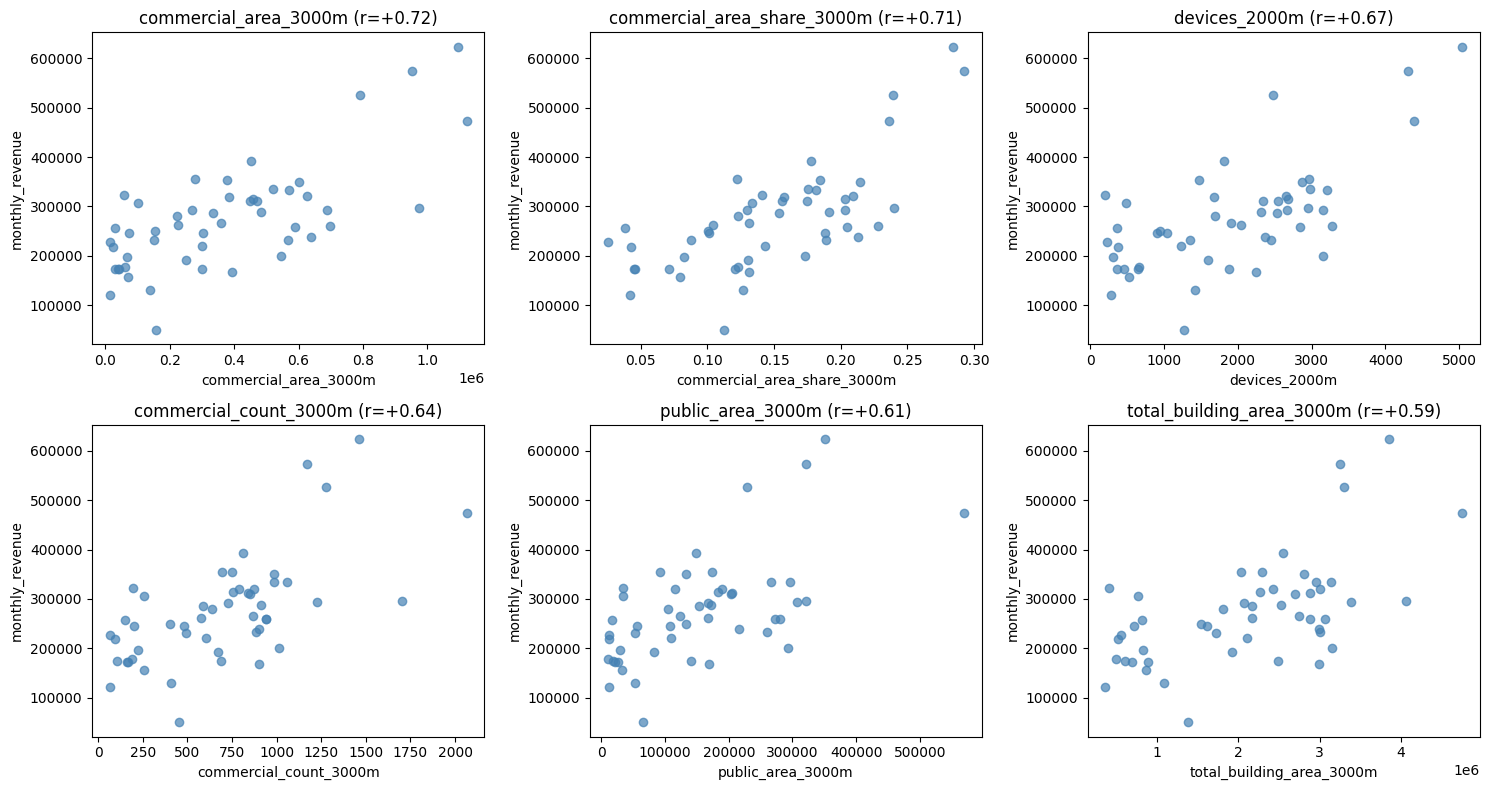

In [14]:
# Top 6 cech wg |corr| z monthly_revenue
numeric = features.select_dtypes(include=np.number).drop(columns=['lat', 'lng', 'monthly_revenue'], errors='ignore')
corrs = numeric.apply(lambda x: x.corr(features['monthly_revenue'])).abs().sort_values(ascending=False)
top6 = corrs.head(6).index.tolist()
print('Top 6 cech wg |corr| z monthly_revenue:')
print(corrs.head(6).round(3).to_string())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(top6):
    axes[i].scatter(features[col], features['monthly_revenue'], alpha=0.7, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('monthly_revenue')
    r = features[col].corr(features['monthly_revenue'])
    axes[i].set_title(f'{col} (r={r:+.2f})')
plt.tight_layout()
plt.show()